# CIFAR-10 Image Classification using CNN

## Objective
To build a Convolutional Neural Network (CNN) using TensorFlow and Keras 
to classify images from the CIFAR-10 dataset into 10 categories.

## About CIFAR-10 Dataset

CIFAR-10 is a benchmark dataset for image classification.
It consists of 60,000 color images of size 32x32 pixels,
divided into 10 different classes.

The dataset contains:
- 50,000 training images
- 10,000 test images
- 10 classes
- RGB images (3 channels)

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


## Dataset Shape Explanation

- 50000 training images
- 10000 test images
- Each image has shape (32, 32, 3)
    - 32 x 32 pixels
    - 3 color channels (Red, Green, Blue)
- Labels are currently integers from 0 to 9

In [3]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat',
    'deer', 'dog', 'frog', 'horse',
    'ship', 'truck'
]

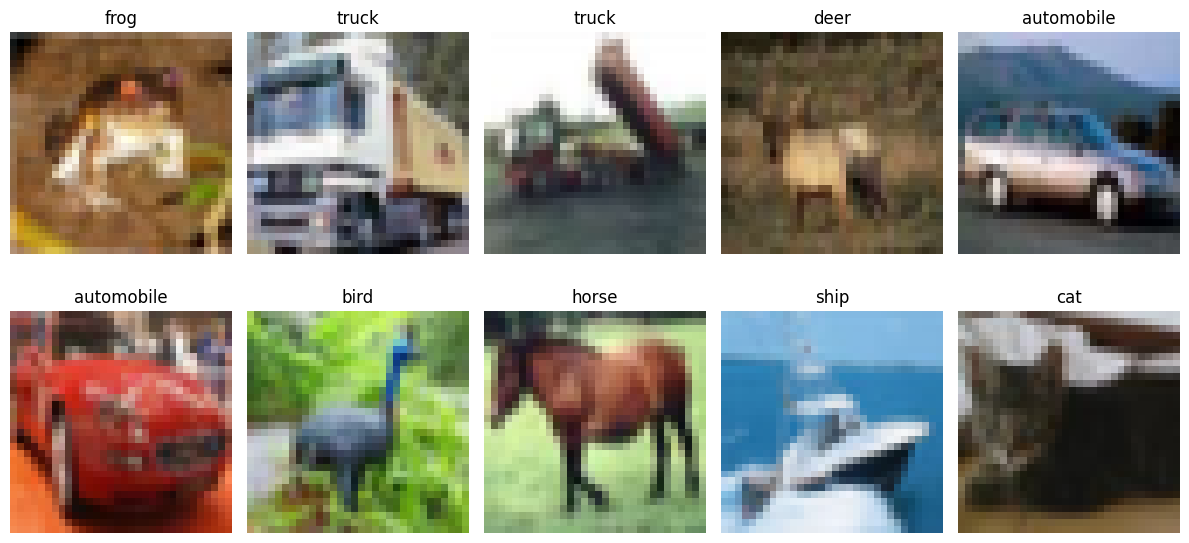

In [4]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Data Visualization

Visualizing sample images helps us:
- Understand image size and clarity
- Observe class diversity
- Verify that data is loaded correctly

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Pixel range after normalization:")
print("Min:", x_train.min())
print("Max:", x_train.max())

Pixel range after normalization:
Min: 0.0
Max: 1.0


## Data Normalization

Pixel values originally range from 0 to 255.
We scale them to the range [0,1] by dividing by 255.

This helps:
- Faster convergence during training
- Stable gradient updates
- Better model performance

In [6]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Label shape after one-hot encoding:", y_train.shape)

Label shape after one-hot encoding: (50000, 10)


## One-Hot Encoding

The model uses categorical_crossentropy loss,
which requires labels in one-hot encoded format.

Example:
Class 3 becomes:
[0,0,0,1,0,0,0,0,0,0]

## CNN Architecture

We design a Convolutional Neural Network with multiple convolutional 
blocks followed by fully connected layers.

The architecture includes:
- Conv2D layers with ReLU activation
- MaxPooling layers for downsampling
- Dropout for regularization
- Dense layers for classification
- Softmax output for 10 classes

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [8]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Flatten layer
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(10, activation='softmax'))

c:\Users\ashifa\Desktop\gpp\CNN-CIFAR10\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## Architectural Justification

- 3 convolutional blocks allow progressive feature extraction.
- Increasing filters (32 → 64 → 128) enables learning more complex patterns.
- 3x3 kernel size is standard for capturing local spatial features.
- MaxPooling reduces spatial dimensions and prevents overfitting.
- Dropout (0.5) reduces overfitting by randomly disabling neurons.
- Softmax output provides probability distribution over 10 classes.

## Model Compilation

We compile the model using:
- Adam optimizer for adaptive learning
- Categorical Crossentropy loss for multi-class classification
- Accuracy as evaluation metric

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Data Augmentation

Data augmentation artificially increases the diversity of training data 
by applying random transformations such as:

- Horizontal flipping
- Rotation
- Width and height shifts

This helps reduce overfitting and improves generalization.

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [12]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

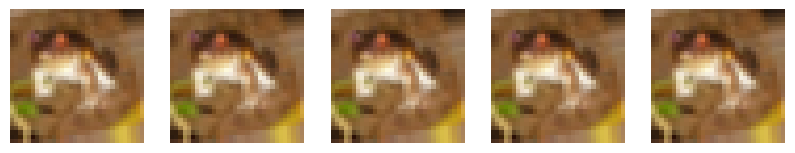

In [13]:
plt.figure(figsize=(10,6))

for X_batch, y_batch in datagen.flow(x_train[:1], y_train[:1], batch_size=1):
    for i in range(5):
        plt.subplot(1,5,i+1)
        plt.imshow(X_batch[0])
        plt.axis('off')
    break

plt.show()

## Learning Rate Scheduling and Model Checkpointing

To improve training stability and performance, we use:

- ReduceLROnPlateau: Reduces learning rate when validation loss stops improving.
- ModelCheckpoint: Saves the best model weights during training.

In [14]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

In [15]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [16]:
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)